In [2]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [3]:
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec
from importlib import reload

In [3]:
from GridMaze.analysis.core import get_clusters as gc

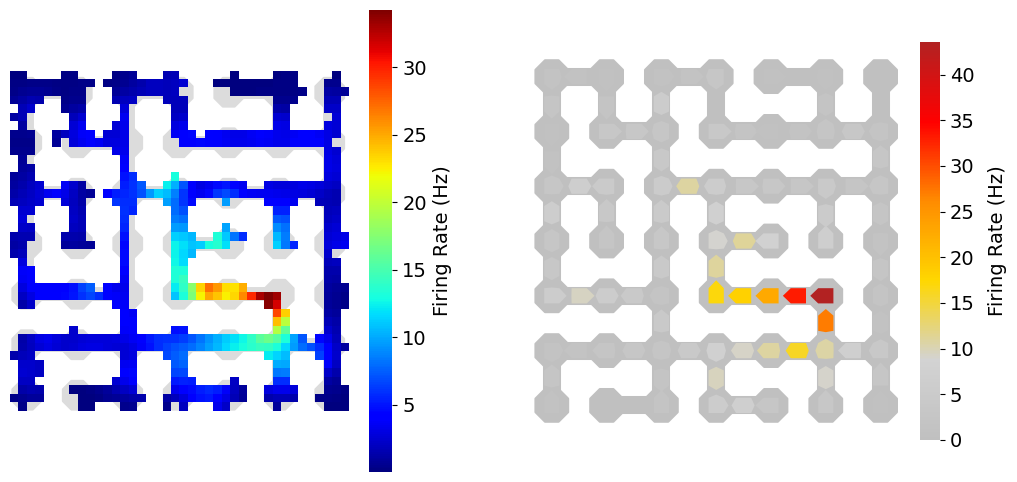

In [12]:
Cluster = gc.get_cluster("m6.2022-06-30.maze_cluster49")
f, axes = plt.subplots(1, 2, figsize=(12, 6))
Cluster.plot_tuning(feature="spatial", ax=axes[0])
Cluster.plot_tuning(feature="place_direction", ax=axes[1])
f.savefig("../results/place_direction/example_place_direction_heatmap.pdf")

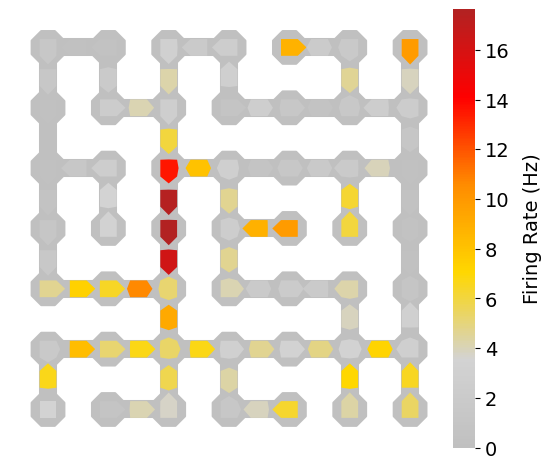

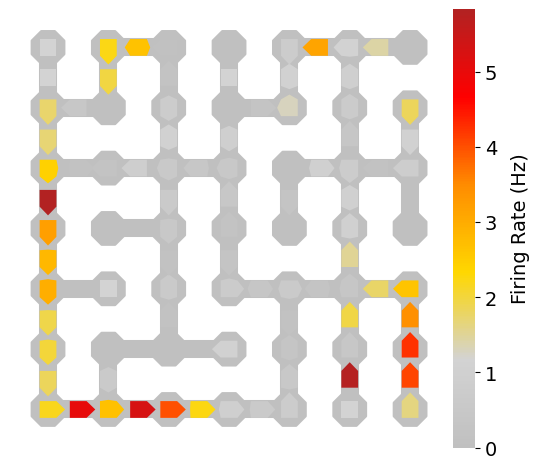

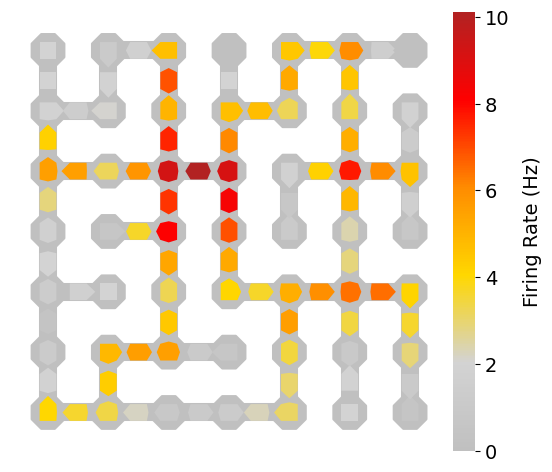

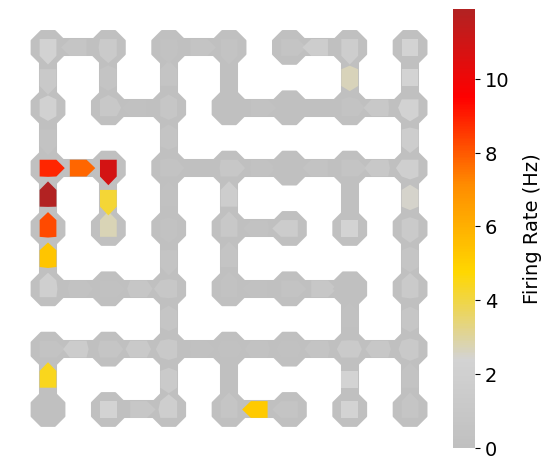

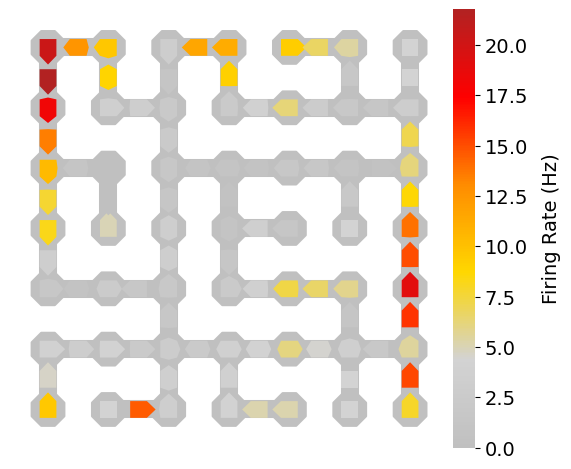

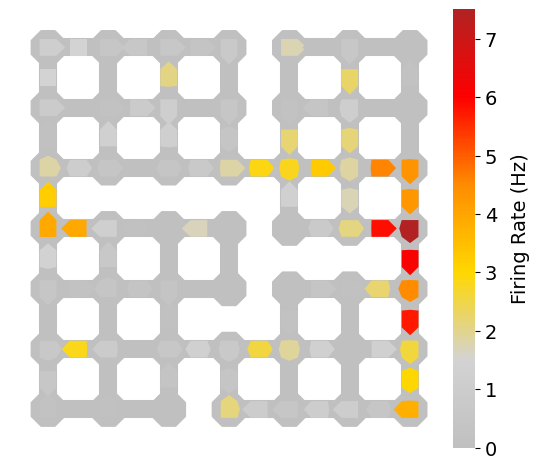

In [13]:
example_clusters = [
    "m3.2022-06-29.maze_cluster85",
    "m3.2022-07-14.maze_cluster6",
    "m3.2022-07-14.maze_cluster85",
    "m6.2022-07-04.maze_cluster52",
    "m6.2022-07-04.maze_cluster94",
    "m3.2022-07-24.maze_cluster65",
]

for cluster in example_clusters:
    f, ax = plt.subplots(1, 1, figsize=(6, 6))
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(
        "place_direction",
        ax=ax,
    )
    f.savefig(f"../results/place_direction/example_clusters/{cluster}.pdf")

No place-direction cluster found with split_half_corr >= 0.5
No place-direction cluster found with split_half_corr >= 0.5
No place-direction cluster found with split_half_corr >= 0.5
No place-direction cluster found with split_half_corr >= 0.5
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.placeDirectionTuningMetrics.parquet not found for m8.2022-07-26.maze
No place-direction cluster found with split_half_corr >= 0.5
No place-direction cluster found with split_half_corr >= 0.5
No place-direction cluster found with split_half_corr >= 0.5
No place-direction cluster found with split_half_corr >= 0.5


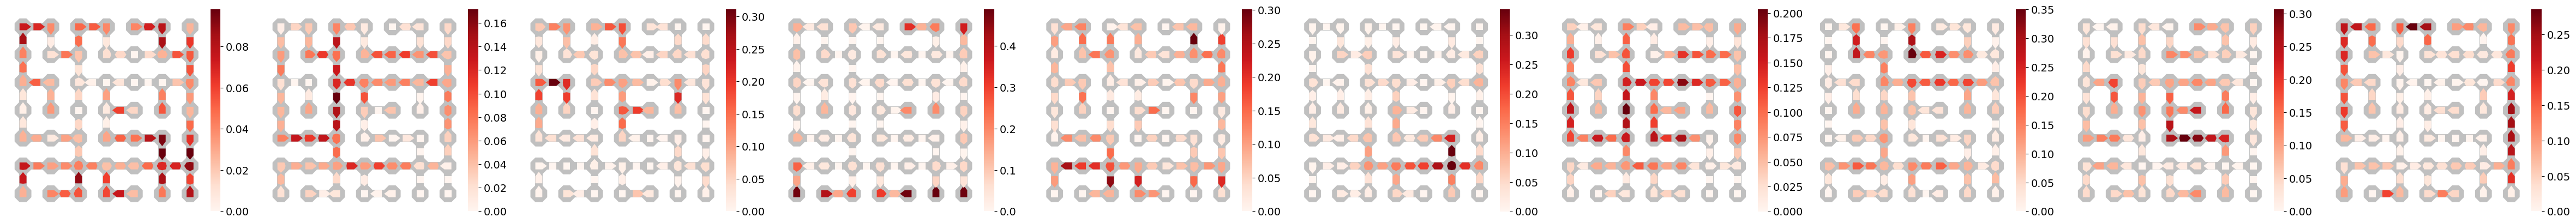

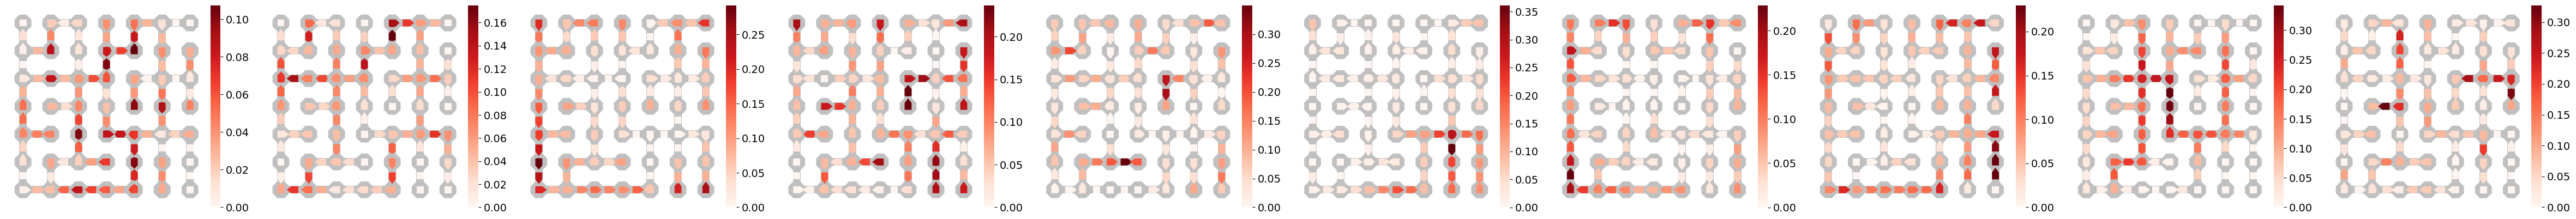

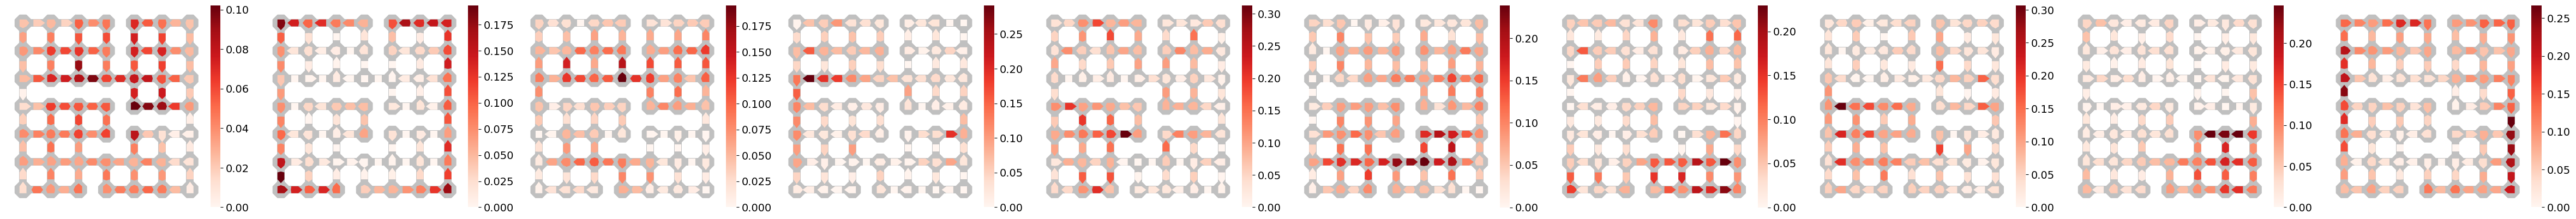

In [14]:
# get population nmf components
from GridMaze.maze import representations as mr
from GridMaze.analysis.place_direction import dimensionality_reduction as dr

reload(dr)

n_components = 10
for maze_name in ["maze_1", "maze_2", "rooms_maze"]:
    f, axes = plt.subplots(1, n_components, figsize=(6 * n_components, 6))
    population_tuning_df = dr.get_population_place_direction_tuning(
        subject_IDs="all",
        maze_name=maze_name,
        late_sessions=True,
    )
    simple_maze = mr.get_simple_maze(maze_name)
    dr.plot_nmf_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="Reds",
        axes=axes,
    )
    f.savefig(f"../results/place_direction/nmf_components/{maze_name}.pdf")

trajectory_decisions.parquet not found for m8.2022-07-26.maze


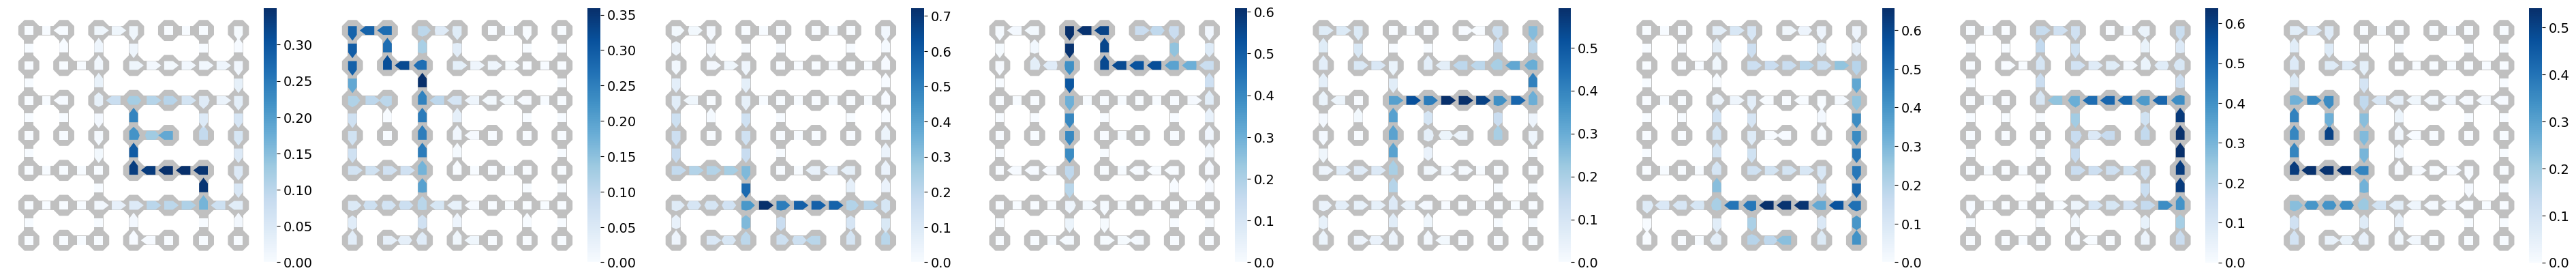

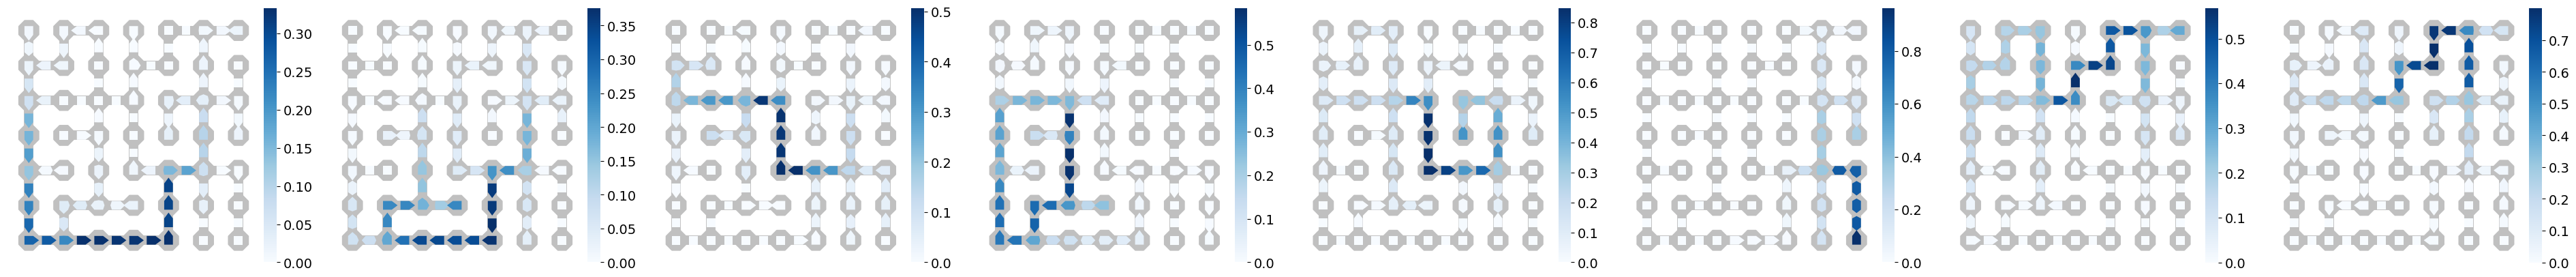

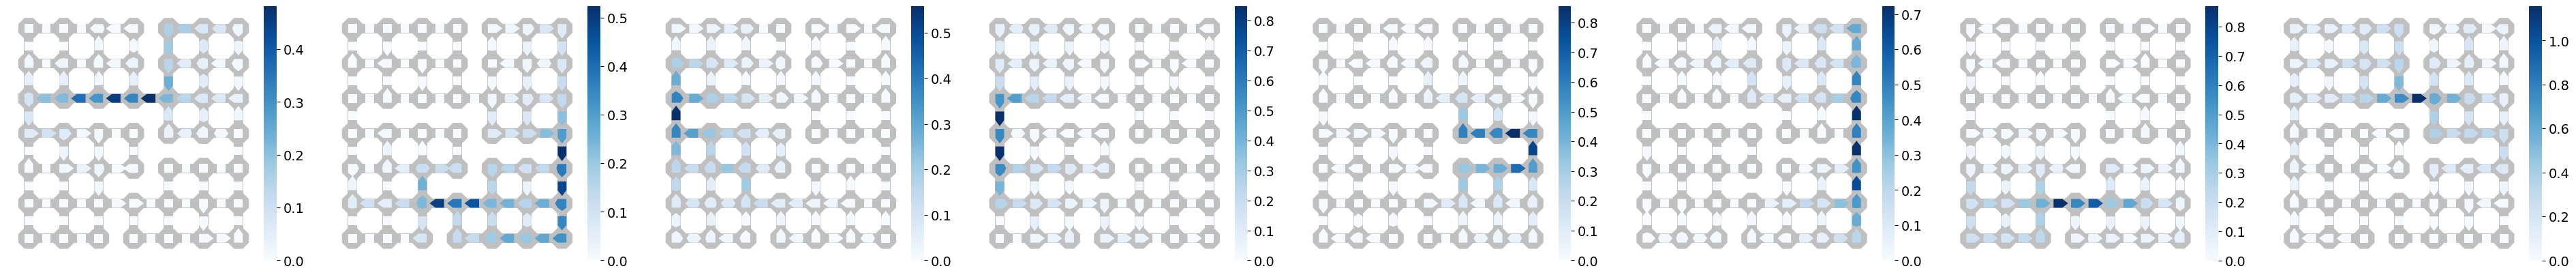

In [15]:
# plot behavioural NMF components for comparison
from GridMaze.analysis.behaviour import dimensionality_reduction as bdr

n_components = 8
for maze_name in ["maze_1", "maze_2", "rooms_maze"]:
    f, axes = plt.subplots(1, n_components, figsize=(6 * n_components, 6))
    population_tuning_df = bdr.get_maze_behavioural_sequences_df(
        subject_IDs="all",
        maze_name=maze_name,
        late_sessions=True,
        max_steps_to_goal=30,
    )
    simple_maze = mr.get_simple_maze(maze_name)
    bdr.plot_nmf_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="Blues",
        axes=axes,
    )
    f.savefig(f"../results/behaviour/nmf_components/{maze_name}.pdf")

In [ ]:
# variance explained analysis
from GridMaze.analysis.place_direction import efficient_coding as ec

sessions = ec.get_analysis_sessions(subject="all", maze="maze_1", late=True)
input_data = ec.get_joint_neural_behaviour_place_direction_dfs(sessions, synthetic_behaviour=False)

In [ ]:
ec.run_neuron_to_behaviour_variance_explained_analysis(input_data, ve_method="pca")